<a href="https://colab.research.google.com/github/isi1993/DRRR/blob/main/YouTube_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1 - Install
!pip install youtube-comment-downloader

# Cell 2 - Scrape Comments
from youtube_comment_downloader import YoutubeCommentDownloader
import pandas as pd

VIDEO_URL = "https://www.youtube.com/watch?v=FRI78tq9Eik"

downloader = YoutubeCommentDownloader()
comments = []

for comment in downloader.get_comments_from_url(VIDEO_URL, sort_by=0):
    comments.append({
        "author": comment["author"],
        "comment": comment["text"],
        "likes": comment["votes"],
        "published_at": comment["time"]
    })
    if len(comments) >= 8200:  # Set your limit here
        break

df = pd.DataFrame(comments)
print(f"Total comments scraped: {len(df)}")
df.head()

Total comments scraped: 2207


,author,comment,likes,published_at
0,@brebmann,That screen privacy feature being software ena...,19K,1 month ago
1,@em_azh,4:09 i can finally hide my single-digit bank b...,13K,1 month ago
2,@SC2point0,At first I thought Marques was literally in th...,8.7K,1 month ago
3,@danielokpotimensah8747,The snow in the background looks like you're i...,511,3 weeks ago
4,@HeisenbergFam,Watching MKBHD before the event is a tradition...,3.1K,1 month ago


In [ ]:
from numpy import transpose


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import re

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')
model = AutoModelForSequenceClassification.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
df.columns

Index(['author', 'comment', 'likes', 'published_at'], dtype='object')

In [ ]:
def sentiment_score(comment):
  tokens = tokenizer.encode(comment, return_tensors='pt')
  result = model(tokens)
  return  int(torch.argmax(result.logits))+1

In [ ]:
df.head()

,author,comment,likes,published_at
0,@brebmann,That screen privacy feature being software ena...,19K,1 month ago
1,@em_azh,4:09 i can finally hide my single-digit bank b...,13K,1 month ago
2,@SC2point0,At first I thought Marques was literally in th...,8.7K,1 month ago
3,@danielokpotimensah8747,The snow in the background looks like you're i...,511,3 weeks ago
4,@HeisenbergFam,Watching MKBHD before the event is a tradition...,3.1K,1 month ago


In [ ]:
#df['Review'] = df['comment'].apply(lambda x: sentiment_score(x[:512]))

In [ ]:
df.head()

,author,comment,likes,published_at
0,@brebmann,That screen privacy feature being software ena...,19K,1 month ago
1,@em_azh,4:09 i can finally hide my single-digit bank b...,13K,1 month ago
2,@SC2point0,At first I thought Marques was literally in th...,8.7K,1 month ago
3,@danielokpotimensah8747,The snow in the background looks like you're i...,511,3 weeks ago
4,@HeisenbergFam,Watching MKBHD before the event is a tradition...,3.1K,1 month ago


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.shape

(2207, 4)

In [ ]:
df.columns

Index(['author', 'comment', 'likes', 'published_at'], dtype='object')

In [ ]:
df = df.reset_index()

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df.columns

Index(['index', 'author', 'comment', 'likes', 'published_at'], dtype='object')

In [ ]:
def sentiment_score(comment):
  tokens = tokenizer.encode(comment, return_tensors='pt')
  result = model(tokens)
  return  int(torch.argmax(result.logits))+1

In [ ]:
df['Review'] = df['comment'].apply(lambda x: sentiment_score(x[:512]))

In [ ]:
df['Review'].value_counts()

,count
Review,
1,658
5,600
3,466
2,286
4,197


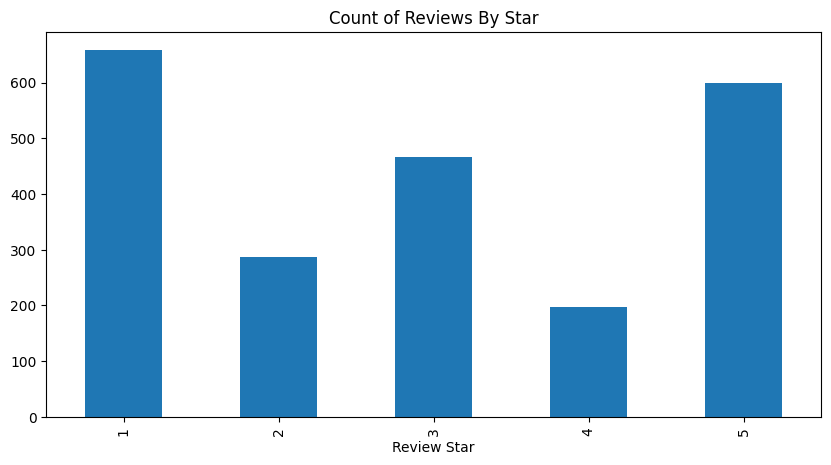

In [ ]:
ax = df['Review'].value_counts().sort_index() \
.plot(kind='bar', title='Count of Reviews By Star', figsize=(10, 5))
ax.set_xlabel('Review Star')
plt.show()

In [ ]:
example = df['comment'][45]
print(example)

Cool if you enjoy your screen quality being cut in half for every app you use it on. It’s a horrible feature made for the 1% of people who care. I won’t buy one simple because it has this feature.


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
tokens = nltk.word_tokenize(example)
tokens[:10]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['Cool',
 'if',
 'you',
 'enjoy',
 'your',
 'screen',
 'quality',
 'being',
 'cut',
 'in']

In [ ]:

from nltk.tag import pos_tag
nltk.download('averaged_perceptron_tagger_eng')
tagged = nltk.pos_tag(tokens)
tagged[:10]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


[('Cool', 'NNP'),
 ('if', 'IN'),
 ('you', 'PRP'),
 ('enjoy', 'VBP'),
 ('your', 'PRP$'),
 ('screen', 'JJ'),
 ('quality', 'NN'),
 ('being', 'VBG'),
 ('cut', 'VBN'),
 ('in', 'IN')]

We will use NLTK's SentimentIntensityAnalyzer to get the neg/neu/pos scores of the text

This uses a "bag of words" approach:

Stop words are removed

each word is scored and combined to a total score.

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
import nltk
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
sia.polarity_scores('I am so happy')

{'neg': 0.0, 'neu': 0.334, 'pos': 0.666, 'compound': 0.6115}

In [ ]:
sia.polarity_scores(example)

{'neg': 0.118, 'neu': 0.698, 'pos': 0.184, 'compound': 0.4767}

In [ ]:
df.columns

Index(['index', 'author', 'comment', 'likes', 'published_at', 'Review'], dtype='object')

In [ ]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    reviewtext = row['comment']
    myid = row['index']
    # Check if reviewtext is a string before processing
    if isinstance(reviewtext, str):
        res[myid] = sia.polarity_scores(reviewtext)
    else:
        # Handle non-string (e.g., NaN) values, assign neutral scores
        res[myid] = {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

  0%|          | 0/2207 [00:00<?, ?it/s]

In [ ]:
df = df.reset_index().rename(columns={'index': 'id'})

In [ ]:
res = pd.DataFrame(res).T
res

,neg,neu,pos,compound
0,0.000,0.772,0.228,0.7351
1,0.195,0.805,0.000,-0.1779
2,0.000,1.000,0.000,0.0000
3,0.000,0.608,0.392,0.7003
4,0.000,1.000,0.000,0.0000
...,...,...,...,...
2202,0.464,0.536,0.000,-0.3802
2203,0.444,0.556,0.000,-0.1531
2204,0.444,0.556,0.000,-0.1531
2205,0.000,0.791,0.209,0.4404


In [ ]:
df.columns

Index(['level_0', 'id', 'author', 'comment', 'likes', 'published_at',
       'Review'],
      dtype='object')

In [ ]:
res = res.reset_index()


In [ ]:
vaders = pd.DataFrame(res)
vaders = vaders.reset_index().rename(columns={'index': 'id'})
vaders = vaders.merge(df, how='left')

In [ ]:
vaders.head()

,level_0,id,neg,neu,pos,compound,author,comment,likes,published_at,Review
0,0,0,0.000,0.772,0.228,0.7351,@brebmann,That screen privacy feature being software ena...,19K,1 month ago,5
1,1,1,0.195,0.805,0.000,-0.1779,@em_azh,4:09 i can finally hide my single-digit bank b...,13K,1 month ago,4
2,2,2,0.000,1.000,0.000,0.0000,@SC2point0,At first I thought Marques was literally in th...,8.7K,1 month ago,2
3,3,3,0.000,0.608,0.392,0.7003,@danielokpotimensah8747,The snow in the background looks like you're i...,511,3 weeks ago,3
4,4,4,0.000,1.000,0.000,0.0000,@HeisenbergFam,Watching MKBHD before the event is a tradition...,3.1K,1 month ago,4


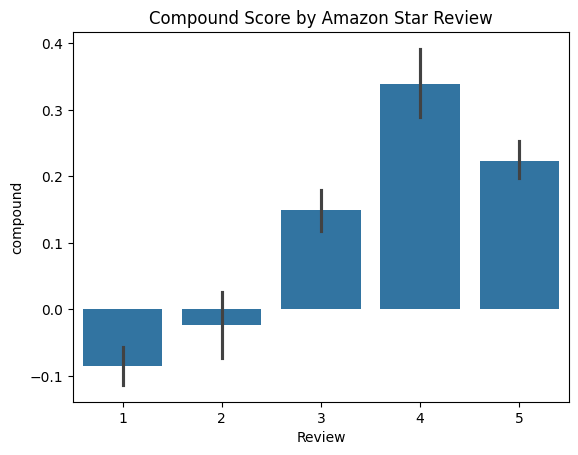

In [ ]:
# plot the varder result
ax = sns.barplot(data=vaders, x='Review', y='compound')
ax.set_title('Compound Score by Amazon Star Review')
plt.show()

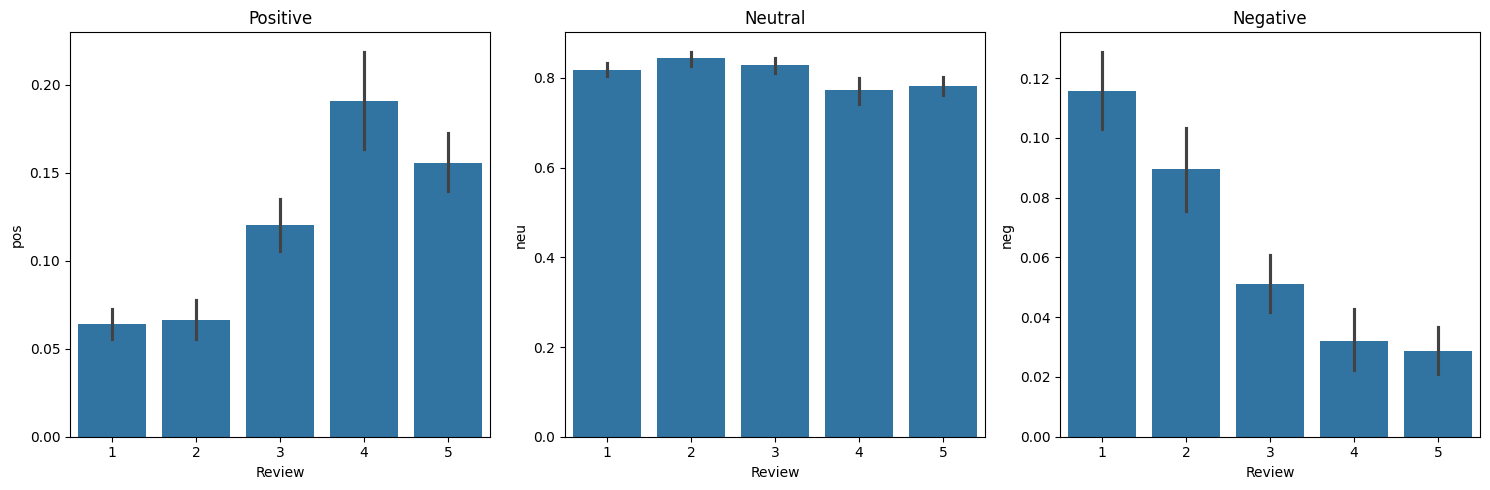

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.barplot(data=vaders, x='Review', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='Review', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='Review', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()

step 3 Roberta Pretrained Model
use a model trained of a large corpus of data
.Transformer model account for the word but also the context related to other words.

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [ ]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#vader result on example
print(example)
sia.polarity_scores(example)

Cool if you enjoy your screen quality being cut in half for every app you use it on. It’s a horrible feature made for the 1% of people who care. I won’t buy one simple because it has this feature.


{'neg': 0.118, 'neu': 0.698, 'pos': 0.184, 'compound': 0.4767}

In [ ]:
# Run for roberta Model
encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)
overall = output[0][0].detach().numpy()
overall = softmax(overall)
overall_dict = {
'roberta_neg' : overall[0],
'roberta_neu' : overall[1],
'roberta_pos' : overall[2]
}
print(overall_dict)

{'roberta_neg': np.float32(0.777666), 'roberta_neu': np.float32(0.1785065), 'roberta_pos': np.float32(0.043827582)}


In [ ]:
def polarity_scores_roberta(example):
    # Truncate input to max_length (typically 512 for RoBERTa) to avoid 'index out of bounds' errors
    encoded_text = tokenizer(example, return_tensors='pt', truncation=True, max_length=512)
    output = model(**encoded_text)
    overall = output[0][0].detach().numpy()
    overall = softmax(overall)
    overall_dict = {
    'roberta_neg' : overall[0],
    'roberta_neu' : overall[1],
    'roberta_pos' : overall[2]
    }
    return overall_dict

In [ ]:
df.columns

Index(['level_0', 'id', 'author', 'comment', 'likes', 'published_at',
       'Review'],
      dtype='object')

In [ ]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    overall = row['comment']
    myreviewerID = row['id']

    if isinstance(overall, str):
        try:
            vaders_result = sia.polarity_scores(overall)
            vaders_result_rename = {}
            for key, value in vaders_result.items():
                vaders_result_rename[f"vader_{key}"] = value
            result_roberta = polarity_scores_roberta(overall)
            both_result = {**vaders_result_rename, **result_roberta}
            res[myreviewerID] = both_result
        except TypeError:
            print(f'broke for id {myreviewerID} during sentiment analysis')
            # Assign neutral scores if sentiment analysis fails due to TypeError
            res[myreviewerID] = {
                'vader_neg': 0.0, 'vader_neu': 1.0, 'vader_pos': 0.0, 'vader_compound': 0.0,
                'roberta_neg': 0.0, 'roberta_neu': 1.0, 'roberta_pos': 0.0
            }
    else:
        # Handle non-string (e.g., NaN) values by assigning neutral scores
        res[myreviewerID] = {
            'vader_neg': 0.0, 'vader_neu': 1.0, 'vader_pos': 0.0, 'vader_compound': 0.0,
            'roberta_neg': 0.0, 'roberta_neu': 1.0, 'roberta_pos': 0.0
        }

  0%|          | 0/2207 [00:00<?, ?it/s]

In [ ]:
result_df = pd.DataFrame(res).T
result_df = result_df.reset_index().rename(columns={'index': 'id'})
result_df = result_df.merge(df, how='left')

In [ ]:
result_df.columns

Index(['id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'level_0', 'author',
       'comment', 'likes', 'published_at', 'Review'],
      dtype='object')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

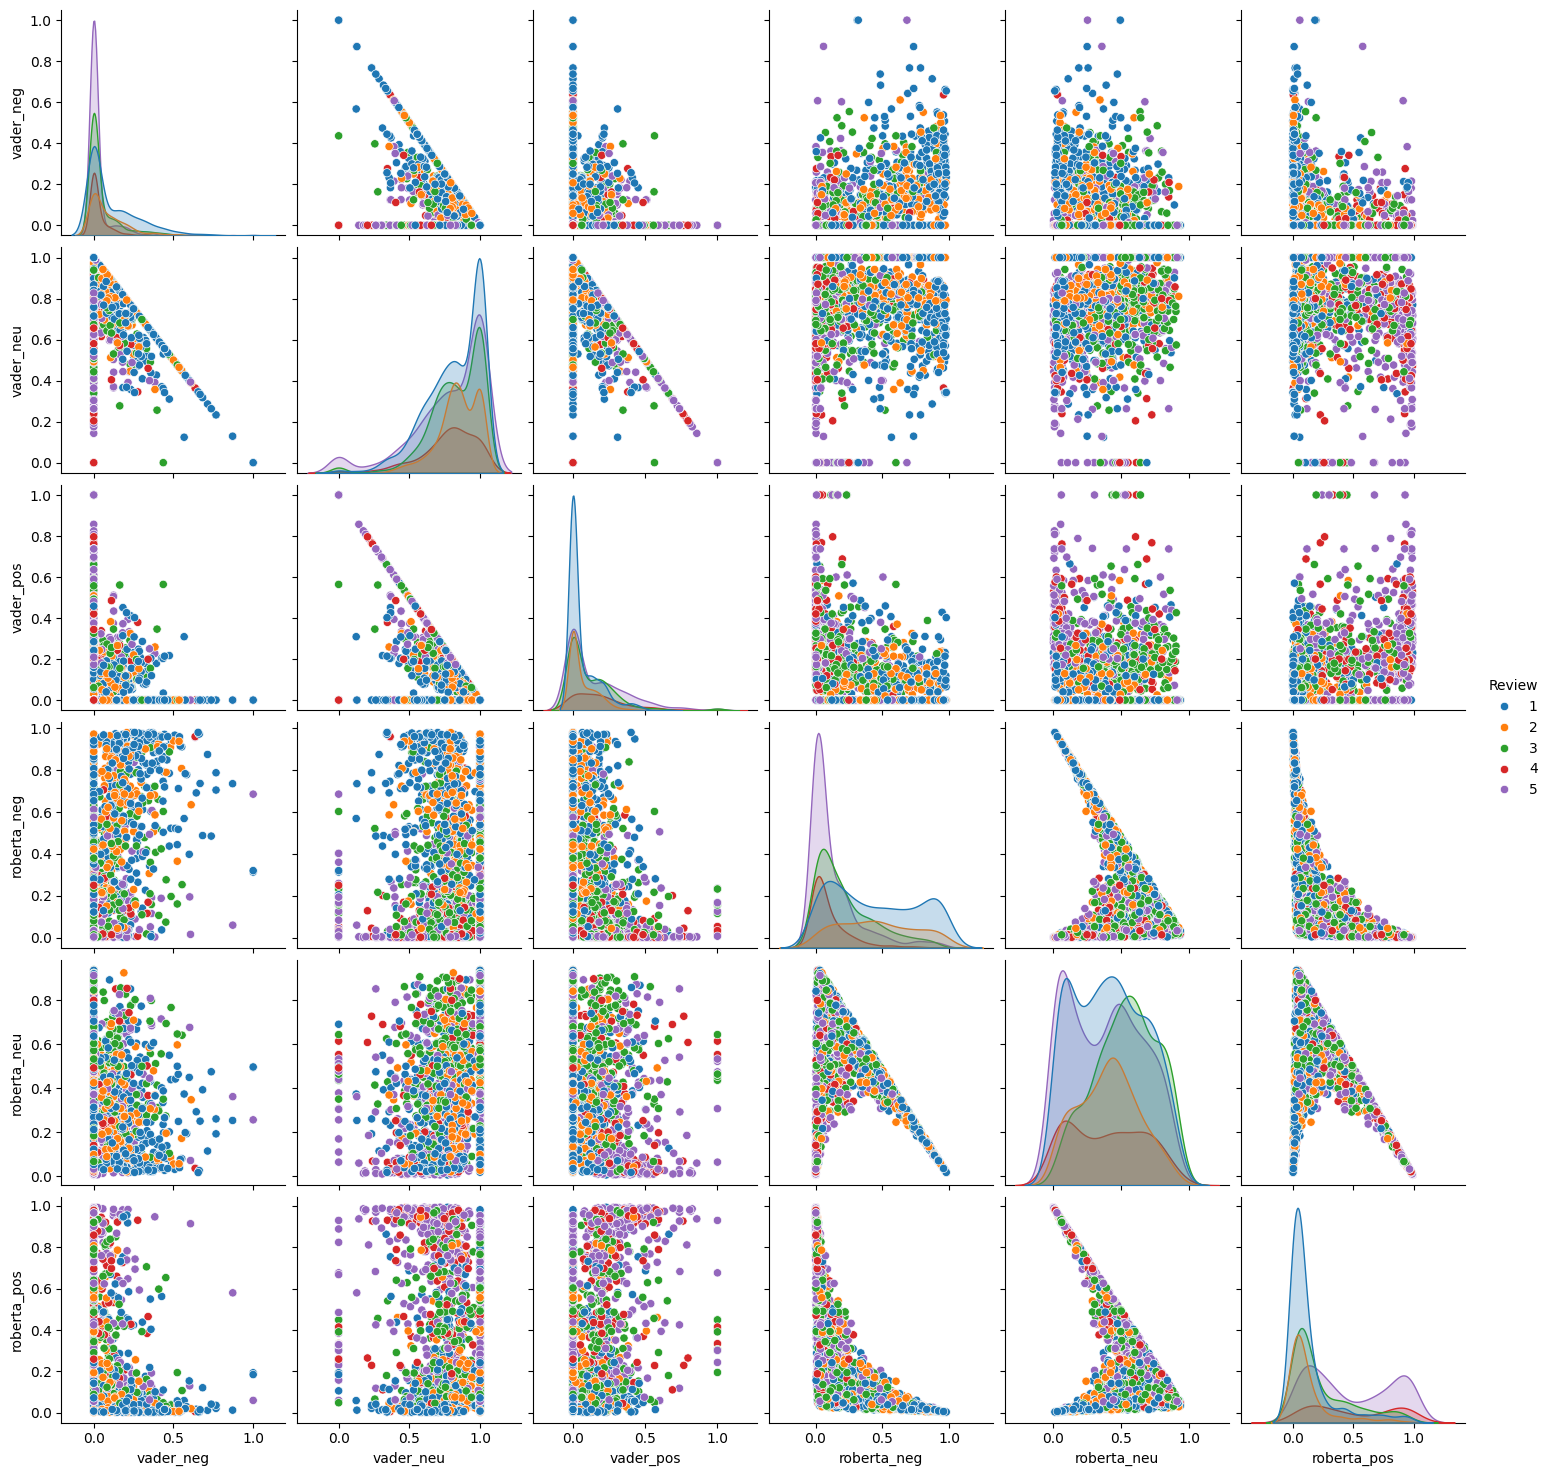

In [ ]:
#compare overall between model
sns.pairplot(data=result_df, vars=['vader_neg', 'vader_neu', 'vader_pos', 'roberta_neg', 'roberta_neu', 'roberta_pos'],
             hue='Review', palette='tab10')
plt.show()

In [ ]:
 result_df.query('Review == 1').sort_values('roberta_pos', ascending=False)['comment'].values[0]

'so excited for apple to release it in 5 years. cant wait!'

In [ ]:

result_df.query('Review == 1') \
    .sort_values('vader_pos', ascending=False)['comment'].values[0]

'\xa0@vndragonslayer1\xa0 Yeah, S26 is way better lol'

In [ ]:
result_df.query('Review == 5') \
    .sort_values('roberta_neg', ascending=False)['comment'].values[0]

'Why do i always do this to myself! 😢 whyyy!?'

In [ ]:
result_df.query('Review == 5') \
    .sort_values('vader_neg', ascending=False)['comment'].values[0]

'fool'

use the pipeline method

In [ ]:
# using pipeline  for sentiment analysis
from transformers import pipeline
sentiment_pipeline = pipeline("sentiment-analysis")
#data = ["I love you"]
#sentiment_pipeline(data)



No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
df['sentiment'] = df['comment'].astype(str).apply(lambda x: sentiment_pipeline(x, truncation=True)[0]['label'])
df.head()

,level_0,id,author,comment,likes,published_at,Review,sentiment
0,0,0,@brebmann,That screen privacy feature being software ena...,19K,1 month ago,5,POSITIVE
1,1,1,@em_azh,4:09 i can finally hide my single-digit bank b...,13K,1 month ago,4,NEGATIVE
2,2,2,@SC2point0,At first I thought Marques was literally in th...,8.7K,1 month ago,2,NEGATIVE
3,3,3,@danielokpotimensah8747,The snow in the background looks like you're i...,511,3 weeks ago,3,POSITIVE
4,4,4,@HeisenbergFam,Watching MKBHD before the event is a tradition...,3.1K,1 month ago,4,POSITIVE


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
NEGATIVE,1609
POSITIVE,598
